In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/pranjaljethva/house-data/Bengaluru_House_Data.csv')
print(df.shape)       # (13320, 9)
print(df.head())
print(df.info())
print(df.isnull().sum())

(13320, 9)
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  obj

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000
area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
['2 BHK' '4 Bedroom' '3 BHK' '4 BHK' '6 Bedroom' '3 Bedroom' '1 BHK'
 '1 RK' '1 Bedroom' '8 Bedroom' '2 Bedroom' '7 Bedroom' '5 BHK' '7 BHK'
 '6 BHK' '5 Bedroom' '11 BHK' '9 BHK' nan '9 Bedroom' '27 BHK'
 '10 Bedroom' '11 Bedroom' '10 BHK' '19 BHK' '16 BHK' '43 Bedroom'
 '14 BHK' '8 BHK' '12 Bedroom' '13 BHK' '18 Bedroom']
['1056' '2600' '1440' '1521' '1200' '1170' '2732' '3300' '1310' '1020'
 '1800' '2785' '1000

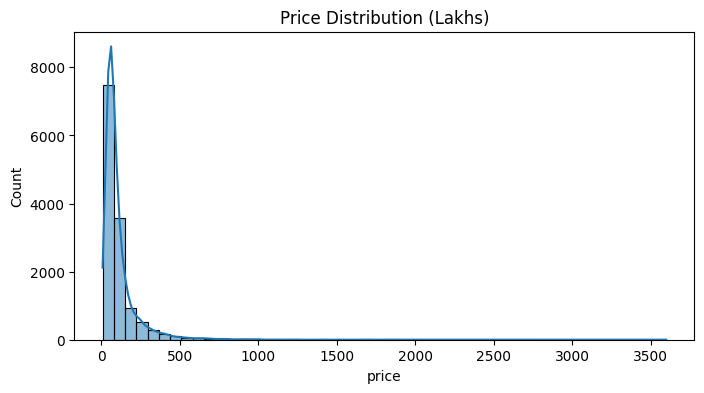

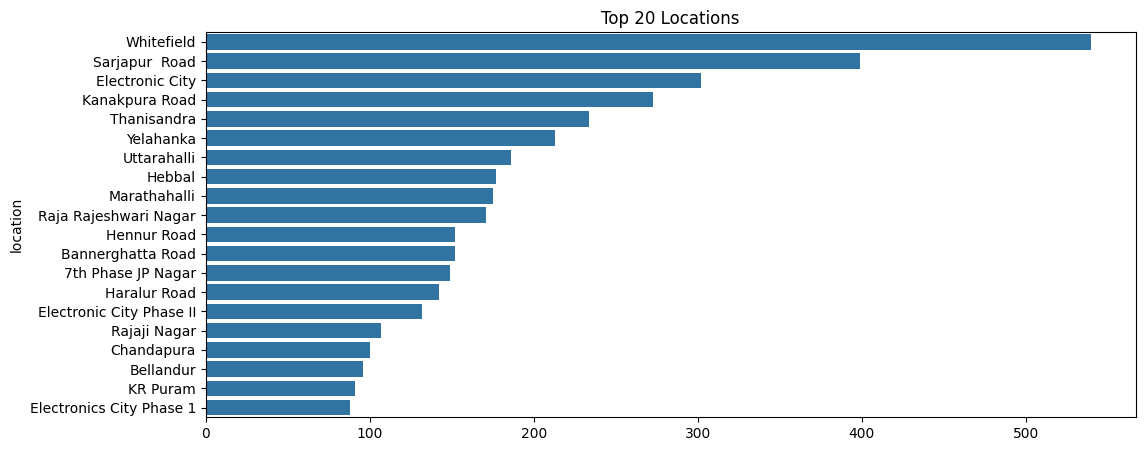

In [6]:
# Basic stats
print(df.describe())
print(df['area_type'].value_counts())
print(df['size'].unique())          # messy: '2 BHK', '2 Bedroom'
print(df['total_sqft'].unique()[:20])  # ranges like '1200-1500'
print(df['location'].nunique())     # 1000+ locations

# Visualize price distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution (Lakhs)')
plt.show()

# Top locations
top_locations = df['location'].value_counts().head(20)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title('Top 20 Locations')
plt.show()

In [7]:
# ── 3a. Drop less useful columns ──────────────────────────────
df.drop(columns=['area_type', 'availability', 'society', 'balcony'],
        inplace=True)

# ── 3b. Drop rows with nulls ──────────────────────────────────
df.dropna(inplace=True)
print("After dropping nulls:", df.shape)

# ── 3c. Extract BHK from 'size' column ────────────────────────
# '2 BHK' → 2, '3 Bedroom' → 3
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
print(df['bhk'].value_counts())
df.drop(columns=['size'], inplace=True)

# ── 3d. Handle 'total_sqft' — ranges and non-numeric ──────────
def convert_sqft(x):
    try:
        # Handle range like '1200-1500' → average
        if '-' in str(x):
            parts = x.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        return float(x)
    except:
        return None   # Sq. Meter, Sq. Yards etc.

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df.dropna(subset=['total_sqft'], inplace=True)
print("After sqft fix:", df.shape)

# ── 3e. Fix location — group rare locations as 'other' ────────
# 1000+ unique locations is too many for encoding
df['location'] = df['location'].str.strip()
location_counts = df['location'].value_counts()

# Locations with <= 10 entries → label as 'other'
rare_locations = location_counts[location_counts <= 10].index
df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)
print("Unique locations after grouping:", df['location'].nunique())
# Should be around 240 — much more manageable

After dropping nulls: (13246, 5)
bhk
2     5527
3     4832
4     1395
1      649
5      353
6      221
7      100
8       89
9       54
10      14
11       4
27       1
19       1
16       1
43       1
14       1
12       1
13       1
18       1
Name: count, dtype: int64
After sqft fix: (13200, 5)
Unique locations after grouping: 241


In [8]:
# ── 4a. Add price_per_sqft ────────────────────────────────────
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']
print(df['price_per_sqft'].describe())

# ── 4b. Remove illogical entries ──────────────────────────────
# Min sqft per BHK should be at least 300 sqft
df = df[~(df['total_sqft'] / df['bhk'] < 300)]
print("After BHK/sqft sanity check:", df.shape)

# ── 4c. Remove price_per_sqft outliers per location ───────────
# Anything beyond mean ± 1 std for that location is an outlier
def remove_price_outliers(df):
    new_df = pd.DataFrame()
    for loc, grp in df.groupby('location'):
        mean = grp['price_per_sqft'].mean()
        std  = grp['price_per_sqft'].std()
        clean = grp[
            (grp['price_per_sqft'] >= mean - std) &
            (grp['price_per_sqft'] <= mean + std)
        ]
        new_df = pd.concat([new_df, clean])
    return new_df.reset_index(drop=True)

df = remove_price_outliers(df)
print("After price/sqft outlier removal:", df.shape)

# ── 4d. Remove BHK anomalies ──────────────────────────────────
# A 2BHK should not cost more than a 3BHK in same location
def remove_bhk_outliers(df):
    exclude = []
    for loc, grp in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_grp in grp.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': bhk_grp['price_per_sqft'].mean(),
                'std' : bhk_grp['price_per_sqft'].std(),
                'count': bhk_grp.shape[0]
            }
        for idx, row in grp.iterrows():
            bhk = row['bhk']
            if bhk >= 2 and (bhk - 1) in bhk_stats:
                if bhk_stats[bhk - 1]['count'] >= 5:
                    if row['price_per_sqft'] < bhk_stats[bhk-1]['mean']:
                        exclude.append(idx)
    return df.drop(index=exclude).reset_index(drop=True)

df = remove_bhk_outliers(df)
print("After BHK anomaly removal:", df.shape)

# ── 4e. Remove bath anomalies ─────────────────────────────────
# Bathrooms should not exceed BHK + 2
df = df[df['bath'] <= df['bhk'] + 2]
print("After bath outlier removal:", df.shape)

# ── 4f. Drop price_per_sqft (leakage) ─────────────────────────
# Not available at prediction time
df.drop(columns=['price_per_sqft'], inplace=True)

count    1.320000e+04
mean     7.920759e+03
std      1.067272e+05
min      2.678298e+02
25%      4.267701e+03
50%      5.438331e+03
75%      7.317073e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64
After BHK/sqft sanity check: (12456, 6)
After price/sqft outlier removal: (10293, 6)
After BHK anomaly removal: (7149, 6)
After bath outlier removal: (7145, 6)


In [9]:
# ── 5a. One-Hot Encode location ───────────────────────────────
df = pd.get_dummies(df, columns=['location'], drop_first=True)
print("Shape after encoding:", df.shape)

# ── 5b. Define X and y ───────────────────────────────────────
X = df.drop(columns=['price'])
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

# ── 5c. Train/Test Split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

# ── 5d. Feature Scaling ───────────────────────────────────────
# Required for Linear, Ridge, Lasso
# Not required for RF/XGBoost but doesn't hurt
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)   # fit ONLY on train!

Shape after encoding: (7145, 244)
X shape: (7145, 243)
y shape: (7145,)
Train: (5716, 243) | Test: (1429, 243)


In [10]:
# Helper function to evaluate any model
def evaluate(name, model, X_tr, X_te, y_tr, y_te, scaled=True):
    Xtr = X_tr if scaled else X_train
    Xte = X_te if scaled else X_test

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, Xtr, y_tr, cv=5,
                           scoring='r2').mean()

    print(f"\n{'─'*40}")
    print(f"Model     : {name}")
    print(f"RMSE      : {rmse:.2f} Lakhs")
    print(f"R² Score  : {r2:.4f}")
    print(f"CV R²     : {cv:.4f}")
    return model, y_pred

# ── 6a. Baseline — Linear Regression ──────────────────────────
lr, lr_pred = evaluate("Linear Regression",
                        LinearRegression(),
                        X_train_sc, X_test_sc, y_train, y_test)

# ── 6b. Ridge Regression ──────────────────────────────────────
ridge, ridge_pred = evaluate("Ridge Regression",
                              Ridge(alpha=10),
                              X_train_sc, X_test_sc, y_train, y_test)

# ── 6c. Lasso Regression ──────────────────────────────────────
lasso, lasso_pred = evaluate("Lasso Regression",
                              Lasso(alpha=1),
                              X_train_sc, X_test_sc, y_train, y_test)

# ── 6d. Random Forest ─────────────────────────────────────────
rf, rf_pred = evaluate("Random Forest",
                        RandomForestRegressor(n_estimators=100,
                                              random_state=42),
                        X_train_sc, X_test_sc, y_train, y_test)

# ── 6e. XGBoost ───────────────────────────────────────────────
xgb, xgb_pred = evaluate("XGBoost",
                           XGBRegressor(n_estimators=200,
                                        learning_rate=0.1,
                                        max_depth=5,
                                        random_state=42),
                           X_train_sc, X_test_sc, y_train, y_test)


────────────────────────────────────────
Model     : Linear Regression
RMSE      : 32.25 Lakhs
R² Score  : 0.8504
CV R²     : 0.8327

────────────────────────────────────────
Model     : Ridge Regression
RMSE      : 32.25 Lakhs
R² Score  : 0.8504
CV R²     : 0.8323

────────────────────────────────────────
Model     : Lasso Regression
RMSE      : 33.28 Lakhs
R² Score  : 0.8407
CV R²     : 0.8240

────────────────────────────────────────
Model     : Random Forest
RMSE      : 31.67 Lakhs
R² Score  : 0.8558
CV R²     : 0.7959

────────────────────────────────────────
Model     : XGBoost
RMSE      : 29.07 Lakhs
R² Score  : 0.8785
CV R²     : 0.8158


In [11]:
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_sc, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R² :", grid.best_score_)

best_model = grid.best_estimator_
y_final    = best_model.predict(X_test_sc)
print("Final R²  :", r2_score(y_test, y_final))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_final)))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best CV R² : 0.8341590679621194
Final R²  : 0.8865319533986085
Final RMSE: 28.089756272608042


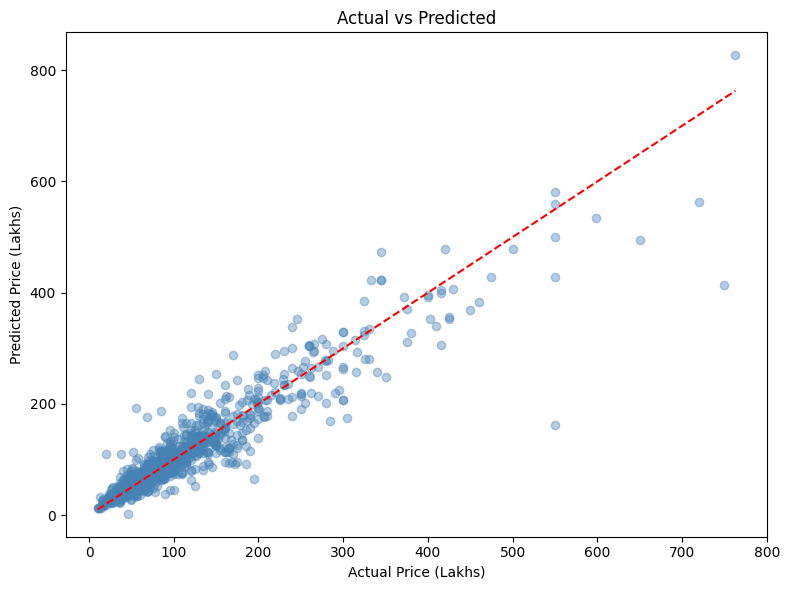

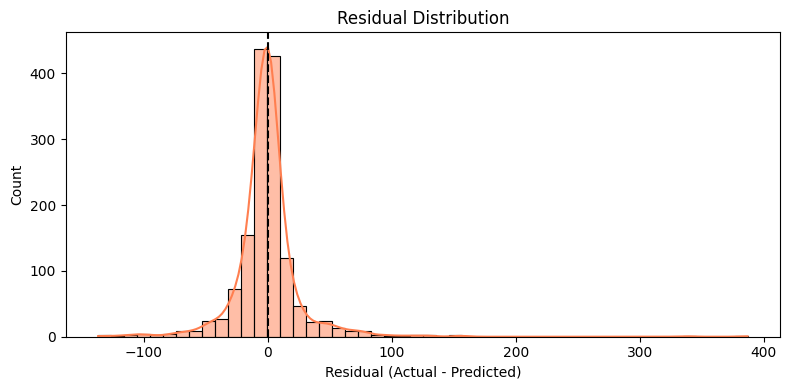

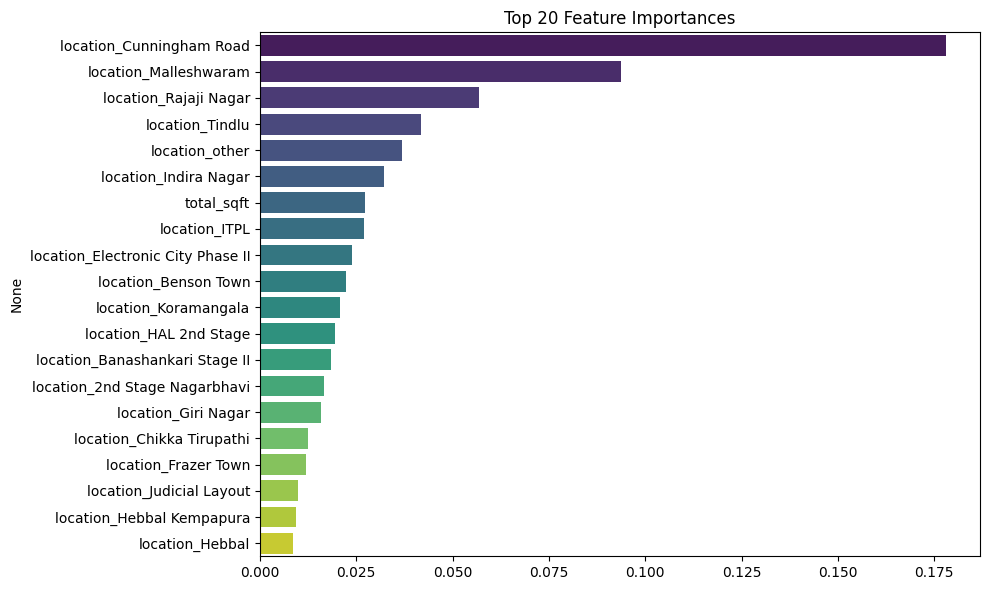

In [12]:
# ── Predicted vs Actual ───────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_final, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# ── Residual Plot ─────────────────────────────────────────────
residuals = y_test - y_final
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# ── Feature Importance ────────────────────────────────────────
importances = pd.Series(best_model.feature_importances_,
                         index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top20.values, y=top20.index, palette='viridis')
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [15]:
import os
import pickle

# Create folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Now save
pickle.dump(best_model, open('models/house_price_model.pkl', 'wb'))
pickle.dump(scaler,     open('models/scaler.pkl', 'wb'))
pickle.dump(list(X.columns), open('models/columns.pkl', 'wb'))

print("Saved successfully!")

Saved successfully!


In [17]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import pickle

# Load saved model, scaler, columns
model   = pickle.load(open('/kaggle/working/models/house_price_model.pkl', 'rb'))
scaler  = pickle.load(open('/kaggle/working/models/scaler.pkl', 'rb'))
columns = pickle.load(open('/kaggle/working/models/columns.pkl', 'rb'))

# Get location list
locations = sorted([c.replace('location_', '') 
                    for c in columns if c.startswith('location_')])

# ── Widgets ───────────────────────────────────────────────────
location_dd = widgets.Dropdown(
    options=locations,
    description='Location:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='350px')
)

sqft_sl = widgets.IntSlider(
    value=1000, min=300, max=5000, step=100,
    description='Sqft:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='350px')
)

bhk_sl = widgets.IntSlider(
    value=2, min=1, max=6, step=1,
    description='BHK:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='350px')
)

bath_sl = widgets.IntSlider(
    value=2, min=1, max=6, step=1,
    description='Bathrooms:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='350px')
)

btn    = widgets.Button(
    description='Predict Price',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

# ── Predict function ──────────────────────────────────────────
def predict(b):
    output.clear_output()
    with output:
        input_data = np.zeros(len(columns))
        input_data[columns.index('total_sqft')] = sqft_sl.value
        input_data[columns.index('bath')]       = bath_sl.value
        input_data[columns.index('bhk')]        = bhk_sl.value

        loc_col = f'location_{location_dd.value}'
        if loc_col in columns:
            input_data[columns.index(loc_col)] = 1

        scaled = scaler.transform([input_data])
        price  = model.predict(scaled)[0]
        per_sqft = (price * 100000) / sqft_sl.value

        print("=" * 40)
        print(f"  Location  : {location_dd.value}")
        print(f"  Size      : {sqft_sl.value} sqft | {bhk_sl.value} BHK | {bath_sl.value} Bath")
        print(f"  Predicted : Rs {price:.2f} Lakhs")
        print(f"  Per sqft  : Rs {per_sqft:,.0f}")
        print("=" * 40)

btn.on_click(predict)

# ── Display UI ────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HTML("<h3>Bangalore House Price Predictor</h3>"),
    location_dd,
    sqft_sl,
    bhk_sl,
    bath_sl,
    btn,
    output
]))